In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from tqdm.autonotebook import tqdm
# from Bio.SeqUtils import seq1
import os
import seaborn as sns

plt.rcParams['figure.dpi'] = 500
plt.rcParams['font.family'] = 'Arial'

# Mapping file 
g2p_meta_path = '/media/drive1/g2p_data/data_releases/2024_04/processed_data/' 
unimeta = pd.read_csv(f'{g2p_meta_path}/uniprot_metadata.tsv',delimiter='\t')
unimeta.index = unimeta.UniprotKB_Entry.tolist()

genemeta = pd.read_csv(f'{g2p_meta_path}/gene_metadata.tsv',delimiter='\t')
genemeta.index = genemeta.HGNC_symbol.tolist()

# Data path 
#score_data = '/home/unix/skwon/Project/Missense/data/proteome-wide/scores/'
score_data = '/media/drive2/seulki/Project/Missense_2025/data/proteomewide/PFES'

# score_decomp_data = '/home/unix/skwon/Project/Missense/data/proteome-wide/scores-decomp/'

# Pathogenicity likelihood curve
df_plp_like = pd.read_csv("/media/drive1/g2p_data/shared_data/plp_likelihood.tsv",delimiter='\t')
# df_plp_like

In [2]:
# # Raw data 
# data_dir = '/home/unix/skwon/Project/Missense/data/variant'
# df_plp_raw = pd.read_csv(f'{data_dir}/pathogenic_annotation_total.txt', delimiter='\t',low_memory=False)
# df_blb_raw = pd.read_csv(f'{data_dir}/benign_annotation_total.txt', delimiter='\t',low_memory=False)
# df_pop_raw = pd.read_csv(f'{data_dir}/population_annotation_total.txt', delimiter='\t',low_memory=False)
# df_vus_raw = pd.read_csv(f'{data_dir}/vus_annotation_total.txt', delimiter='\t',low_memory=False)

# Enter a gene 

In [9]:
gene_name = 'BID'

In [10]:
# UniProtKB accession
uid = genemeta.loc[gene_name].UniprotKB_Entry

In [11]:
def plot_heatmap(df_score, title = 'Protein Feature Enrichment Score: All', max = None):
    # plot the df_score heatmap for the same protein
    plt.figure(figsize=(23,6))
    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]
    df_score_plot = df_score.set_index('RefAA')
    df_score_plot.index = pos_list
    df_score_plot.index.name = 'RefAA'
    if 'average' in df_score_plot.columns:
        df_score_plot = df_score_plot.drop(columns=['average'])
    
    if max == None:
        max = np.max([abs(df_score_plot.max().max()), abs(df_score_plot.min().min())])
    ax = sns.heatmap(df_score_plot.T.iloc[:, 0:], cmap='coolwarm', vmax=max, vmin=-max)
    
    # xlabel 
    ax.set_xlabel('Reference Amino Acid', fontsize=15)
    ax.set_ylabel('Mutated Amino Acid', fontsize=15)
    ax.set_title(title, fontsize=20)

    # # Set x-axis labels
    every = int(df_score_plot.shape[0]/15)
    tics = np.arange(df_score_plot.shape[0])[:-every:every].tolist() + [df_score_plot.shape[0]-1]
    ax.set_xticks(tics)
    ax.set_xticklabels(df_score_plot.iloc[tics].index)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    # set colorbar font 
    cbar = ax.collections[0].colorbar
    cbar.set_label('Score', fontsize=15)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)
    
    plt.show()
    
def plot_heatmap_1D(df_score, title = 'Protein Feature Enrichment Score', max = None):
    # plot the df_score heatmap for the same protein
    plt.figure(figsize=(24,0.5))
    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]
    df_score_plot = df_score.set_index('RefAA')
    df_score_plot.index = pos_list
    df_score_plot.index.name = 'RefAA'
    if 'average' in df_score_plot.columns:
        df_score_plot = df_score_plot.drop(columns=['average'])
    
    if max == None:
        max = np.max([abs(df_score_plot.max().max()), abs(df_score_plot.min().min())])
    ax = sns.heatmap(df_score_plot.T.iloc[:, 0:], cmap='coolwarm', vmax=max, vmin=-max)
    
    # # xlabel 
    ax.set_xlabel('Reference Amino Acid', fontsize=15)
    ax.set_ylabel('  ', fontsize=15)
    ax.set_title(title, fontsize=20)

    # # # Set x-axis labels
    every = int(df_score_plot.shape[0]/15)
    tics = np.arange(df_score_plot.shape[0])[:-every:every].tolist() + [df_score_plot.shape[0]-1]
    ax.set_xticks(tics)
    ax.set_xticklabels(df_score_plot.iloc[tics].index)
    ax.set_yticks([])
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    # set colorbar font 
    cbar = ax.collections[0].colorbar
    cbar.set_label('Score', fontsize=15)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)
    
    # remove colorbar
    # ax.collections[0].colorbar.remove()
    plt.show()
    /media/drive2/seulki/Project/Missense_2025/data/enrichment-drop/summary
    

### Plot the heatmap for the protein 

In [12]:
unimeta

,UniprotKB_Entry,HGNC_id,HGNC_symbol,AlphaFold,PANTHER_protein_class,Canonical_Protein_Isoform,All_Protein_Isoforms,UniProtKB_Isoform_Ensembl_RefSeq,PDBinfo,Isoform_sequence,PDB_monomeric,PDB_homomeric,PDB_multimeric,PDB_mutant,isoform_mapping
P04217,P04217,HGNC:5,A1BG,P04217,defense/immunity protein,P04217-1,P04217-1;P04217-2,P04217;P04217-1(*);ENSG00000121410;ENSP0000026...,-,MSMLVVFLLLWGVTWGPVTEAAIFYETQPSLWAESESLLKPLANVT...,NaN,NaN,NaN,NaN,P04217-1(*);ENST00000263100;NM_130786
Q9NQ94,Q9NQ94,HGNC:24086,A1CF,Q9NQ94,RNA metabolism protein,Q9NQ94-1,Q9NQ94-1;Q9NQ94-2;Q9NQ94-3;Q9NQ94-4;Q9NQ94-5;Q...,Q9NQ94;Q9NQ94-1(*);ENSG00000148584;ENSP0000036...,2CPD(A),MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,NaN,NaN,NaN,NaN,Q9NQ94-1(*);ENST00000373993;NM_001198819;NM_13...
P01023,P01023,HGNC:7,A2M,P01023,protein-binding activity modulator,P01023,P01023,P01023;P01023(*);ENSG00000175899;ENSP000003239...,"1BV8(A);2P9R(A,B);6TAV(A,B,C,D);7O7L(A,B,C,D);...",MGKNKLLHPSLVLLLLVLLPTDASVSGKPQYMVLVPSLLHTETTEK...,1BV8(A)[1336];7VON(A);7VOO(A),"2P9R(A,B)[23,23];6TAV(A,B,C,D);7O7L(A,B,C,D);7...",NaN,NaN,P01023(*);ENST00000318602;NM_000014;NM_0013474...
A8K2U0,A8K2U0,HGNC:23336,A2ML1,A8K2U0,protein-binding activity modulator,A8K2U0-1,A8K2U0-1;A8K2U0-2,A8K2U0;A8K2U0-1(*);ENSG00000166535;ENSP0000029...,"7Q1Y(A,B);7Q5Z(A);7Q60(A);7Q61(A);7Q62(A,B)",MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,7Q5Z(A);7Q60(A);7Q61(A),"7Q1Y(A,B);7Q62(A,B)",NaN,NaN,A8K2U0-1(*);ENST00000299698;NM_144670&A8K2U0-2...
U3KPV4,U3KPV4,HGNC:30005,A3GALT2,U3KPV4,metabolite interconversion enzyme,U3KPV4,U3KPV4,U3KPV4;U3KPV4(*);ENSG00000184389;ENSP000004752...,-,MALKEGLRAWKRIFWRQILLTLGLLGLFLYGLPKFRHLEALIPMGV...,NaN,NaN,NaN,NaN,U3KPV4(*);ENST00000442999;NM_001080438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q6WRX3,Q6WRX3,HGNC:32058,ZYG11A,Q6WRX3,not-available,Q6WRX3-1,Q6WRX3-1;Q6WRX3-2,Q6WRX3;Q6WRX3-1(*);ENSG00000203995;ENSP0000036...,-,MVHFLHPGHTPRNIVPPDAQKDALGCCVVQEEASPYTLVNICLNVL...,NaN,NaN,NaN,NaN,Q6WRX3-1(*);ENST00000371528;NM_001004339&Q6WRX...
Q9C0D3,Q9C0D3,HGNC:25820,ZYG11B,Q9C0D3,not-available,Q9C0D3-1,Q9C0D3-1;Q9C0D3-2,Q9C0D3;Q9C0D3-1(*);ENSG00000162378;ENSP0000029...,"7EP0(A,B);7EP1(A,B);7EP2(A,B,C,D);7XV7(A,B);7X...",MPEDQAGAAMEEASPYSLLDICLNFLTTHLEKFCSARQDGTLCLQE...,NaN,"7EP0(A,B);7EP1(A,B);7EP2(A,B,C,D);7XV7(A,B);7X...",NaN,NaN,Q9C0D3-1(*);ENST00000294353;NM_024646
Q15942,Q15942,HGNC:13200,ZYX,Q15942,cytoskeletal protein,Q15942-1,Q15942-1;Q15942-2,Q15942;Q15942-1(*);ENSG00000159840;ENSP0000032...,-,MAAPRPSPAISVSVSAPAFYAPQKKFGPVVAPKPKVNPFRPGDSEP...,NaN,NaN,NaN,NaN,Q15942-1(*);ENST00000322764;ENST00000646695;NM...
O43149,O43149,HGNC:29027,ZZEF1,not-available,not-available,O43149-1,O43149-1;O43149-2;O43149-3,O43149;O43149-1(*);ENSG00000074755;ENSP0000037...,-,MGNAPSHSSEDEAAAAGGEGWGPHQDWAAVSGTTPGPGVAAPALPP...,NaN,NaN,NaN,NaN,O43149-1(*);ENST00000381638;NM_015113


In [13]:
pclass

NameError: name 'pclass' is not defined

In [14]:
df_by_class_features = pd.read_csv("/media/drive2/seulki/Project/Missense_2025/data/enrichment-drop/summary/class_OR_processed_common+benign.csv")#/home/unix/skwon/Project/Missense/data/gnomad_v2-enrichment/enrichment-drop/summary/OR_byclass_common+benign.csv")
df_by_class_features.rename(columns={'Unnamed: 0':'Feature'},inplace=True)

plist = df_by_class_features.columns.tolist()
plist.remove('Feature')

pclass = unimeta.loc[uid].PANTHER_protein_class
pclass =  pclass.replace(" ","_").replace('/',",")
if pclass == 'not-available':
    pclass = 'unclassified'
    
if pclass in plist:
    print (f"PANTHER protein class: {pclass}")
    feat = df_by_class_features.iloc[df_by_class_features[pclass].dropna().index].Feature.tolist()
    case_feat = df_by_class_features[df_by_class_features[pclass] > 1.0].Feature.tolist()
    cont_feat = df_by_class_features[df_by_class_features[pclass] < 1.0].Feature.tolist()
    df_this_class = df_by_class_features[df_by_class_features.Feature.isin(feat)][['Feature',pclass]]
else:
    print (f"PANTHER protein class: {pclass} (small sample size)")
    feat = df_by_class_features.iloc[df_by_class_features['unclassified'].dropna().index].Feature.tolist()
    case_feat = df_by_class_features[df_by_class_features['unclassified'] > 1.0].Feature.tolist()
    cont_feat = df_by_class_features[df_by_class_features['unclassified'] < 1.0].Feature.tolist()
    df_this_class = df_by_class_features[df_by_class_features.Feature.isin(feat)][['Feature','unclassified']]
    
print('list of features and odd ratio:')
for item in df_this_class.values:
    print(item)

PANTHER protein class: unclassified
list of features and odd ratio:
['Aliphatic>Aliphatic' 0.43]
['Aliphatic>Aromatic' 1.48]
['Aliphatic>Polar/Neutral' 0.78]
['Aliphatic>Positively-Charged' 4.95]
['Aliphatic>Negatively-Charged' 3.19]
['Aliphatic>Special' 2.52]
['Aromatic>Polar/Neutral' 4.13]
['Aromatic>Positively-Charged' 2.47]
['Aromatic>Negatively-Charged' 6.6]
['Aromatic>Special' 3.91]
['Polar/Neutral>Aliphatic' 0.42]
['Polar/Neutral>Aromatic' 1.7]
['Polar/Neutral>Polar/Neutral' 0.37]
['Polar/Neutral>Negatively-Charged' 0.6]
['Positively-Charged>Aliphatic' 2.12]
['Positively-Charged>Polar/Neutral' 0.62]
['Positively-Charged>Positively-Charged' 0.46]
['Positively-Charged>Special' 1.59]
['Negatively-Charged>Aliphatic' 1.87]
['Negatively-Charged>Aromatic' 4.88]
['Negatively-Charged>Negatively-Charged' 0.47]
['Special>Aromatic' 6.42]
['Special>Polar/Neutral' 0.73]
['Special>Positively-Charged' 1.88]
['Special>Negatively-Charged' 1.52]
['Special>Special' 5.29]
['Mild' 0.44]
['Moderate' 0

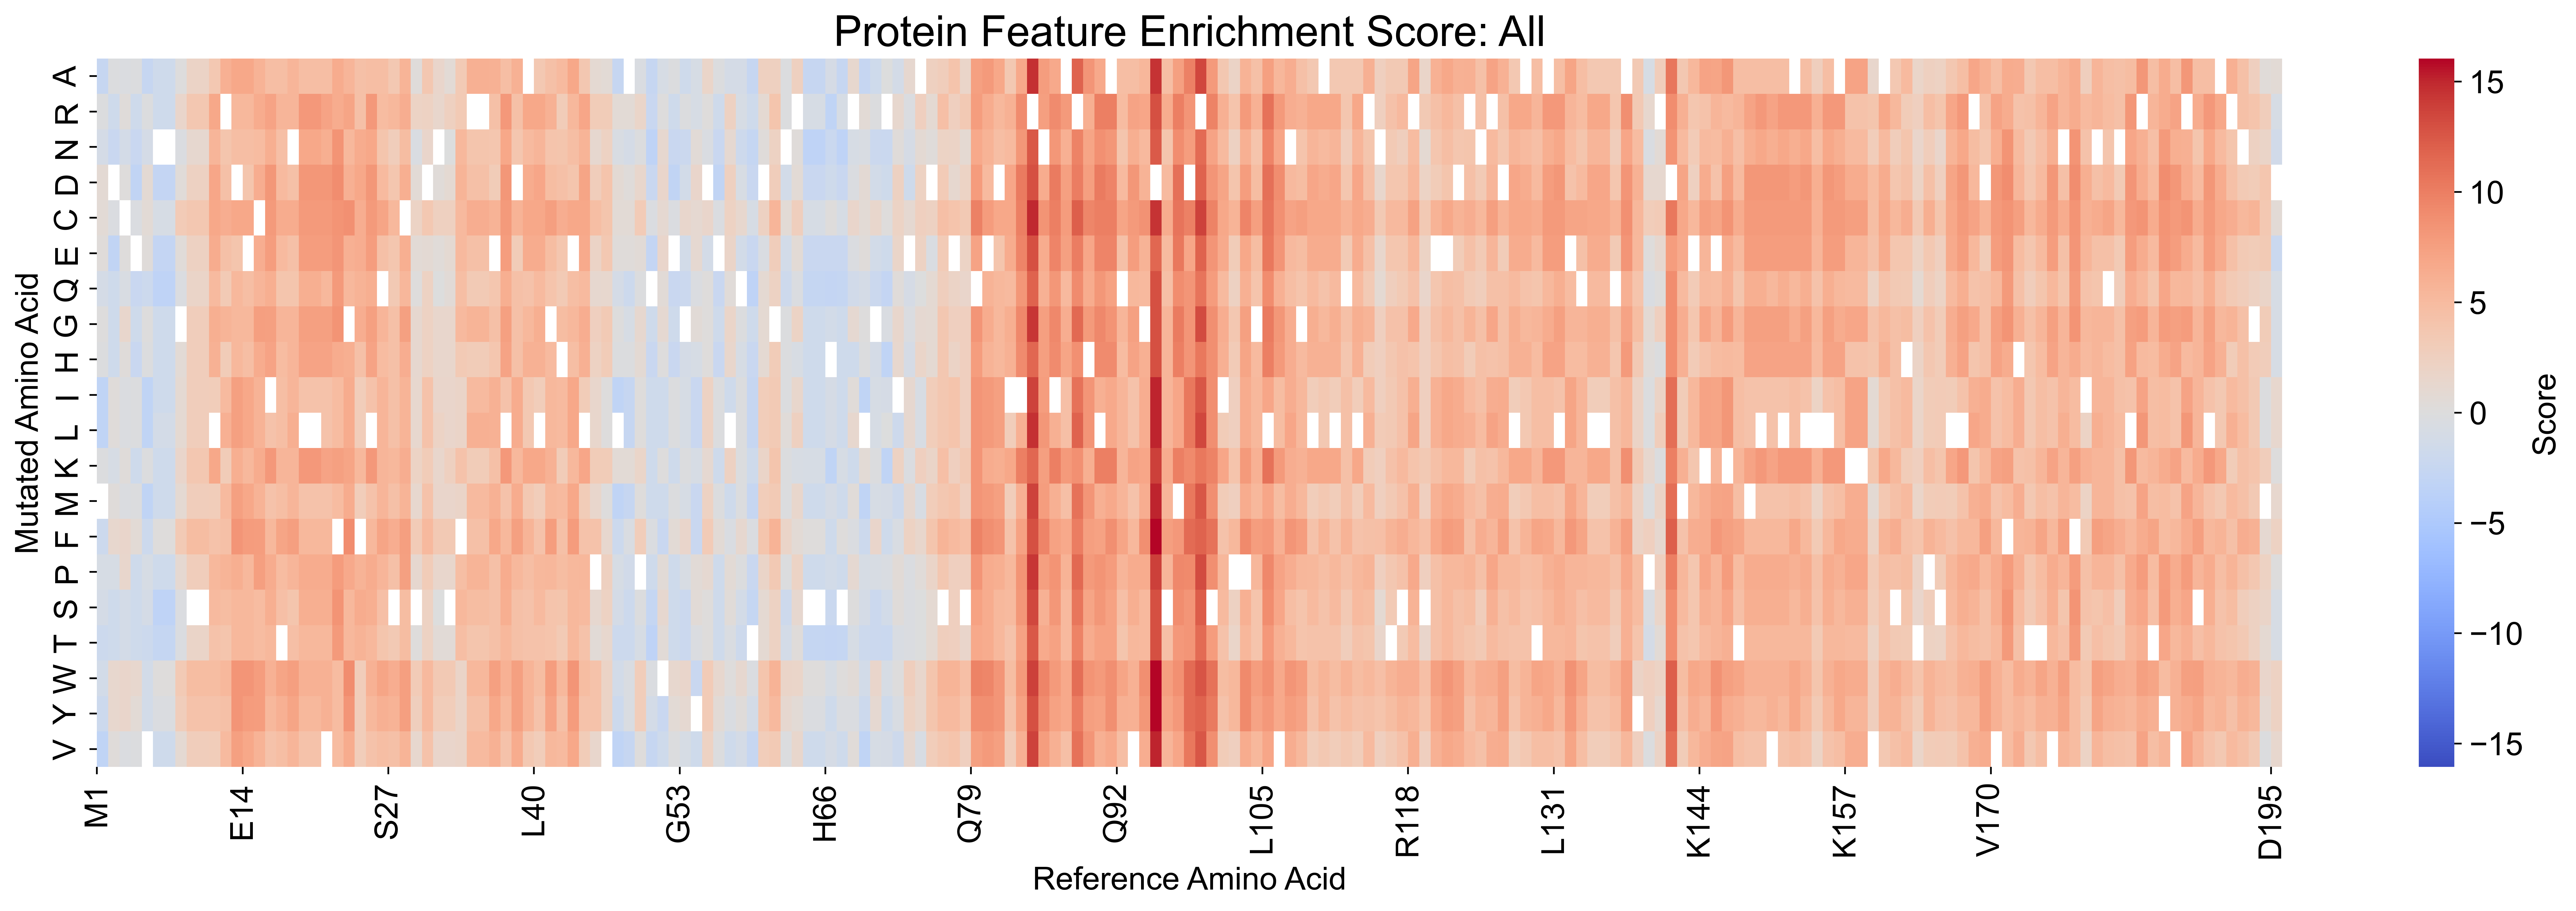

NameError: name 'score_decomp_data' is not defined

In [15]:
# All features
score_file = f"{score_data}/scores_class_{uid}.txt"
if os.path.exists(score_file):
    df_score = pd.read_csv(f"{score_data}/scores_class_{uid}.txt",sep='\t')
    df_score_list = pd.read_csv(f"{score_data}/scores_class_list_{uid}.txt",sep='\t')
    plot_heatmap(df_score)
    total_max = df_score.drop(columns=['RefAA']).max().max()

mops = ['Physicochemical', 'Activity', 'Structure', 'Modification', 'PPI']
score_file = f"{score_decomp_data}/scores_class_list_{uid}_decomp.txt"

# Decomposed features
if os.path.exists(score_file):
    df_score_decomp = pd.read_csv(f"{score_decomp_data}/scores_class_list_{uid}_decomp.txt",sep='\t')

    mop = 'Physicochemical'
    df_score_plot = pd.DataFrame()
    df_score_plot['RefAA'] = df_score_decomp['RefAA'] 
    aas = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K','M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
    for alt in aas: 
        df_score_plot[alt] = df_score_decomp[alt].apply(lambda x: eval(x)[mop])
    
    # plot_heatmap(df_score_plot, title = f'Protein Feature Enrichment Score: {mop}')
    plot_heatmap(df_score_plot, title = f'Protein Feature Enrichment Score: {mop}', max=total_max/2.0)

    df_score_plot = pd.DataFrame()
    df_score_plot['RefAA'] = df_score_decomp['RefAA']
    for mop in ['Activity', 'Structure', 'Modification', 'PPI']:
        df_score_plot[f'{mop}'] = df_score_decomp['A'].apply(lambda x: eval(x)[mop]).tolist()
        # plot_heatmap_1D(df_score_plot[['RefAA',f'{mop}']], title = f'Protein Feature Enrichment Score: {mop}')
        plot_heatmap_1D(df_score_plot[['RefAA',f'{mop}']], title = f'Protein Feature Enrichment Score: {mop}', max=total_max/2.0)
    

In [9]:
# # All features

# score_file = f"{score_data}/scores_class_{uid}.txt"
# # if os.path.exists(score_file):
# df_score = pd.read_csv(f"{score_data}/scores_class_{uid}.txt",sep='\t')

# # plot the df_score heatmap for the same protein
# plt.figure(figsize=(12, 3))
# df_score_plot = df_score.set_index('RefAA')
# df_score_plot_range = df_score_plot#.iloc[heatmap_index]    # print(min,max)
# df_score_plot_range = df_score_plot_range.drop(columns=['average'])
# ax = sns.heatmap(df_score_plot_range.T.iloc[:, 0:], cmap='coolwarm', cbar_kws={'label': 'Score'})
# # xlabel 
# ax.set_xlabel('Position')
# ax.set_ylabel('Altered Amino Acid')
# ax.set_title(f"PFES score")

# df_plp = df_plp_raw[df_plp_raw.Gene == gene_name]
# df_blb = df_blb_raw[df_blb_raw.Gene == gene_name]
# df_pop = df_pop_raw[df_pop_raw.Gene == gene_name]
# df_common = df_pop_raw[df_pop_raw.Gene == gene_name]
# df_common = df_common[df_common.AF_category == 'Common']
# df_intermediate = df_pop_raw[df_pop_raw.Gene == gene_name]
# df_intermediate = df_intermediate[df_intermediate.AF_category == 'Intermediate']
# df_rare = df_pop_raw[df_pop_raw.Gene == gene_name]
# df_rare = df_rare[df_rare.AF_category == 'Rare']

     
# # plot the location of df_pparg mutations
# for i in range(len(df_plp)):
#     refaa = df_plp.iloc[i].RefAA
#     resid = df_plp.iloc[i].ResID
#     altaa = df_plp.iloc[i].AltAA
#     plt.text(resid-1, df_score_plot.columns.tolist().index(altaa), 'x', fontsize=10, color='red')
    
    
# # df_cont = df_rare[df_rare.AlleleCount > 1] #pd.concat([df_blb, df_pop])
# # for i in range(len(df_cont)):
# #     refaa = df_cont.iloc[i].RefAA
# #     resid = df_cont.iloc[i].ResID
# #     altaa = df_cont.iloc[i].AltAA
# #     plt.text(resid-1, df_score_plot.columns.tolist().index(altaa), 'x', fontsize=10, color='blue')
    
# plt.show()


# Enter a mutation

In [12]:
mutation = 'M1V'

### pathogenicity likelihood curve

Total PFE Score 
 : -5.28
 : correspoding to 0.3% likelihood of pathogenicity 

Decomposed PFE Score 
: {'Physicochemical': -1.66, 'Activity': 0, 'Structure': -3.61, 'Modification': 0, 'PPI': 0} 

List of features;Odd ratio 
 :['Aliphatic>Aliphatic;0.43', 'Mild;0.44', 'C;0.27', 'Very low;0.1'] 



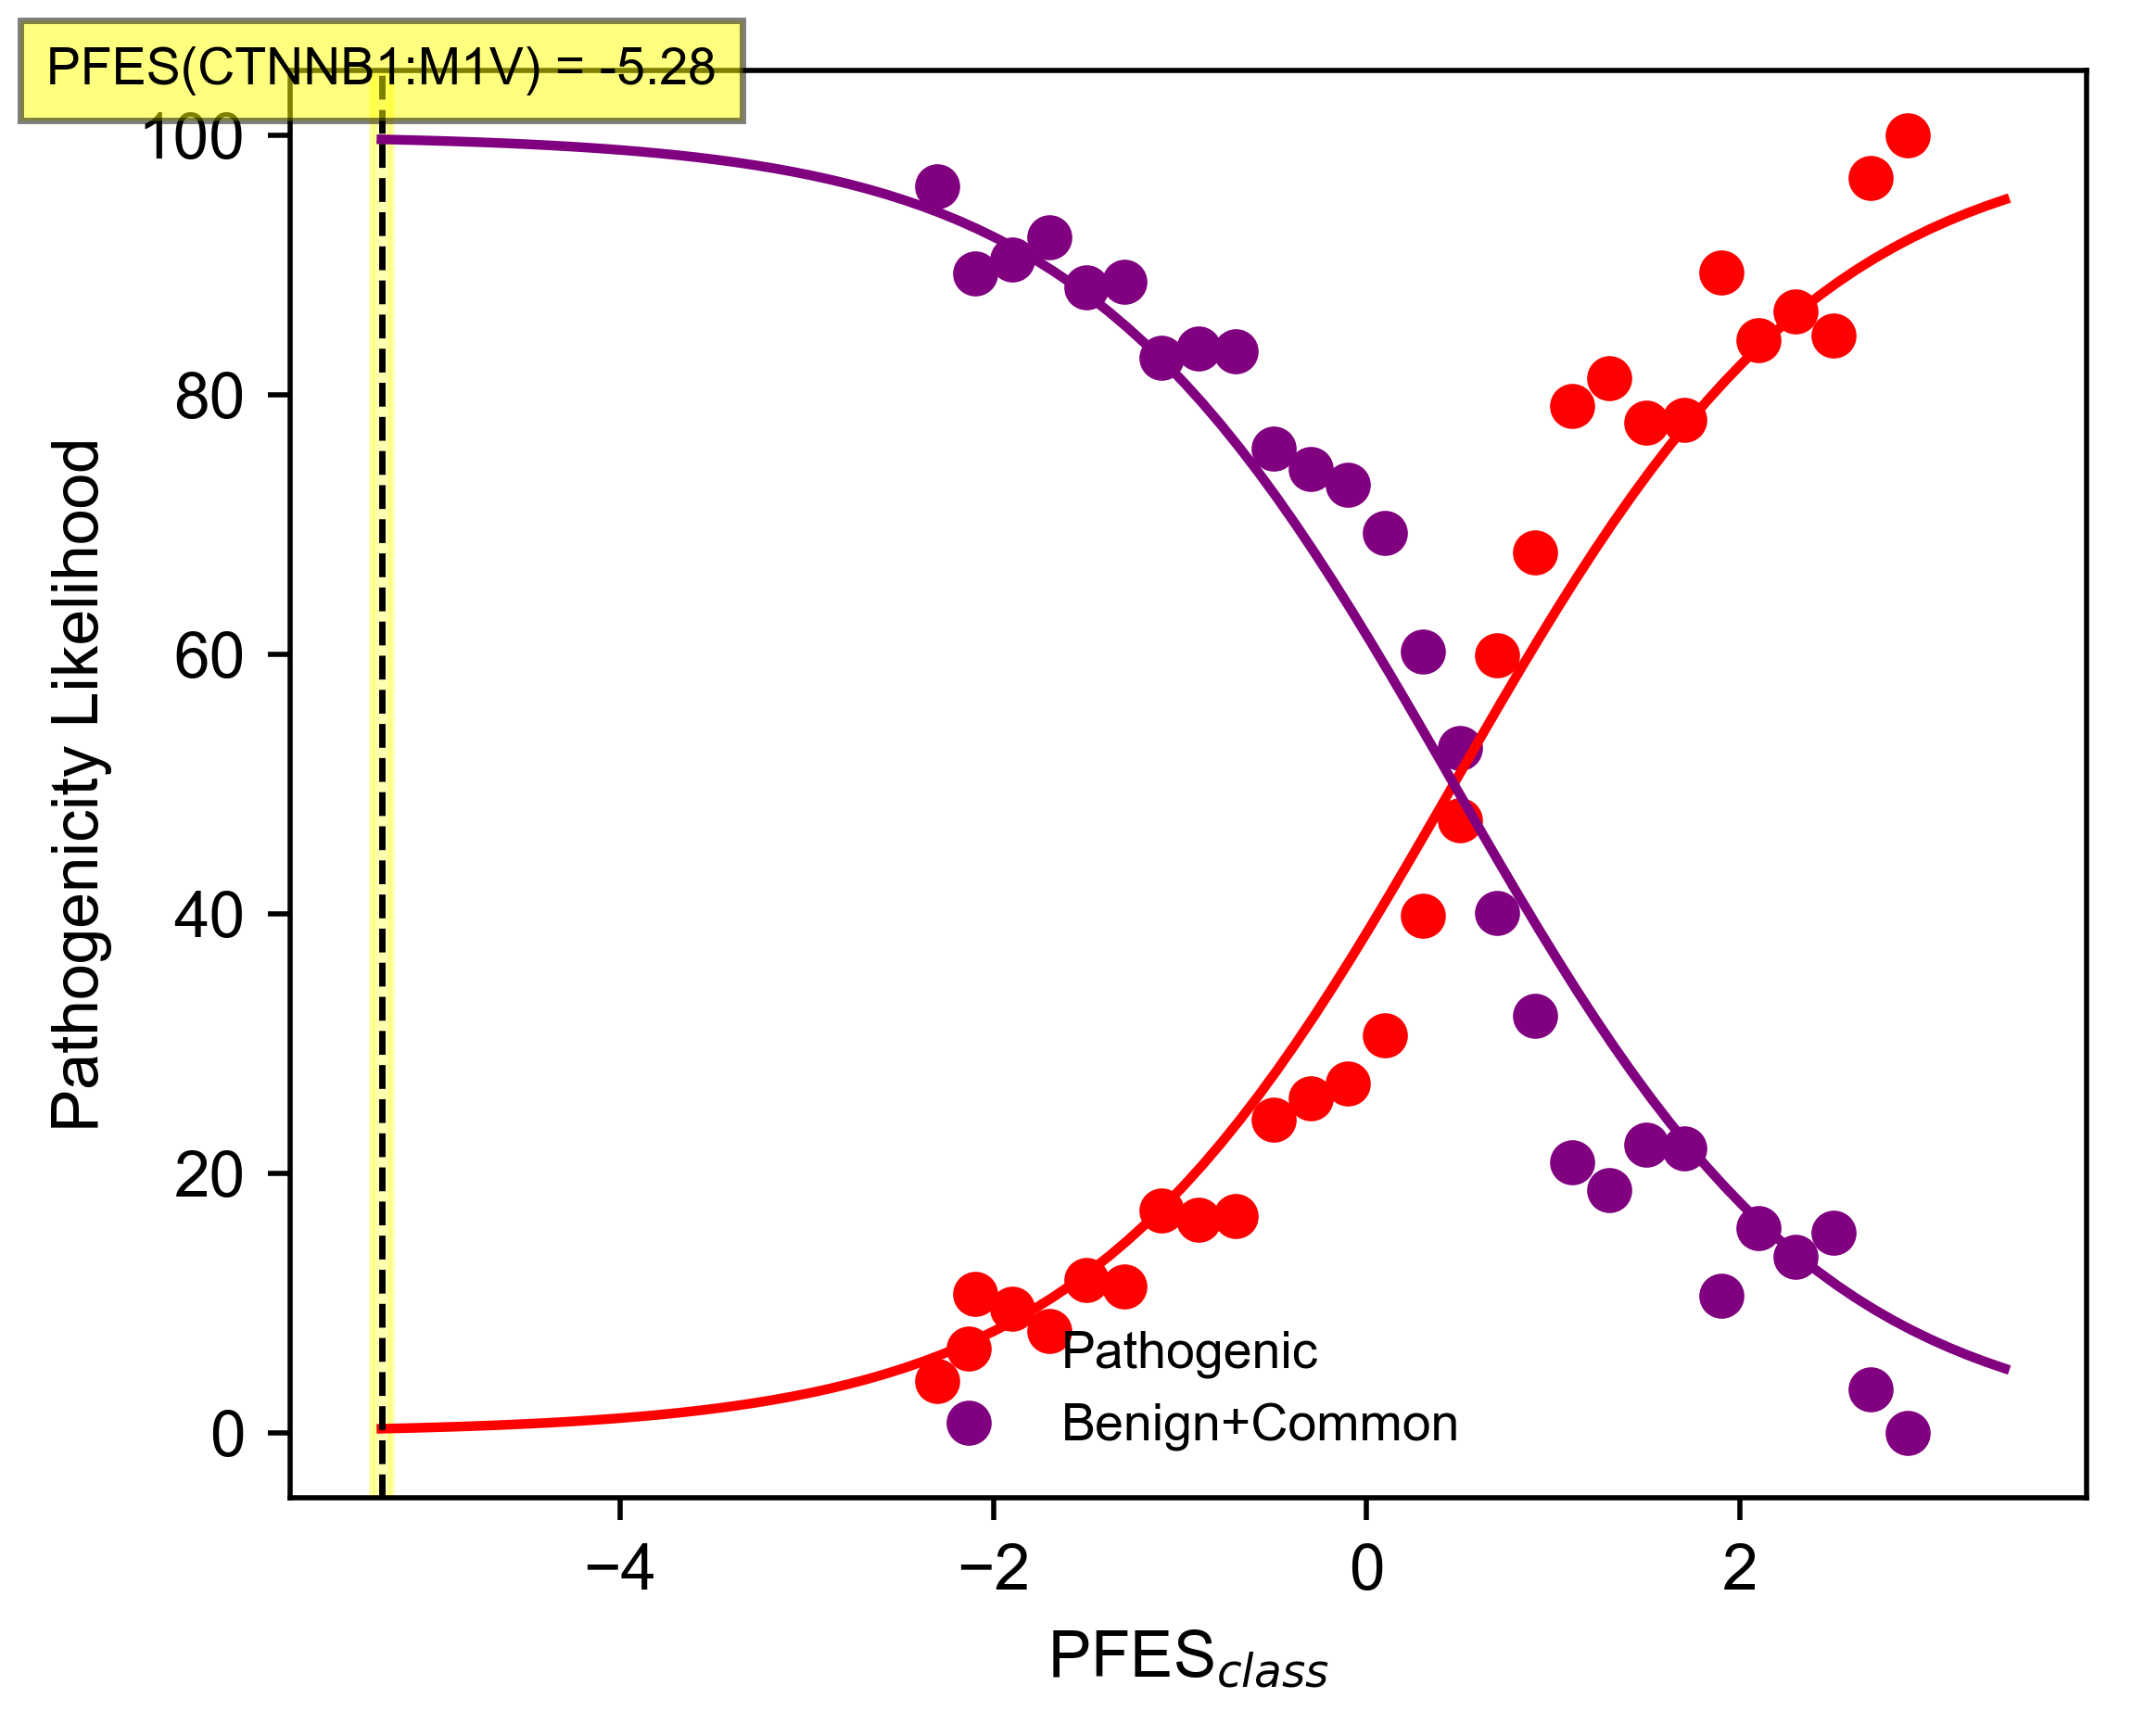

In [13]:
# smooth line (2nd polynomial) fit to the data points
z = np.polyfit(df_plp_like.Center, df_plp_like['PLP dominance'], 2)
p_plp = np.poly1d(z)

from scipy.optimize import curve_fit
# Define the sigmoid function
def sigmoid(x, x0, k):
    return 100 / (1 + np.exp(-k * (x - x0)))
# Extract data from your DataFrame
x_data = df_plp_like.Center
y_data = df_plp_like['PLP dominance']
# Fit the sigmoid curve to the data
popt, pcov = curve_fit(sigmoid, x_data, y_data, method='dogbox', bounds=([-np.inf, 0], [np.inf, 1]))
# popt contains the optimal values for x0 and k
x0, k = popt
# Create a callable sigmoid function similar to `p_plp`
p_plp = lambda x: sigmoid(x, x0, k)

# Check if valid
refaa = mutation[0]
resid = int(mutation[1:-1])
mutaa = mutation[-1]

pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]

if mutation[0:-1] in pos_list:
    try: 
        this_mut_score = df_score.iloc[resid-1][mutaa]
        this_mut_list = df_score_list.iloc[resid-1][mutaa].split(",")
        this_mut_decomp = df_score_decomp.iloc[resid-1][mutaa]
        print (f'Total PFE Score \n : {this_mut_score}')
        
        closest_row = df_plp_like.iloc[(df_plp_like['Center'] - this_mut_score).abs().argmin()]#['Center']
        print (f" : correspoding to {p_plp(this_mut_score):.1f}% likelihood of pathogenicity \n")
               
        print (f'Decomposed PFE Score \n: {eval(this_mut_decomp)} \n')
        print (f'List of features;Odd ratio \n :{this_mut_list} \n')

    except:
        print(f'Error: Mutation {mutation} not a valid mutation')

else:
    print(f'Error: Mutation {mutation} not found in the score file, reference AA is {df_score.iloc[resid-1].RefAA}{resid}')
    
center = np.array(df_plp_like.Center)
dat_plp = np.array(df_plp_like['PLP dominance'])
dat_blb = np.array(df_plp_like['BLB dominance'])

plt.figure(figsize=(5, 4))
plt.plot(center, dat_plp, label='Pathogenic', color = 'red', marker='o', linewidth=0)
plt.plot(center, dat_blb, label='Benign+Common', color = 'purple', marker='o', linewidth = 0)
plt.xlabel('PFES$_{class}$')
plt.ylabel('Pathogenicity Likelihood')
plt.legend(frameon=False, loc = 'lower center', fontsize=8)

default_max = 3.5
range_max = max(default_max, this_mut_score )
range_min = min(-default_max, this_mut_score )
x_fit_range = np.arange(range_min, range_max, 0.1)
plt.plot(x_fit_range, p_plp(x_fit_range),  color = 'red', linestyle='-')
plt.plot(x_fit_range, 100-p_plp(x_fit_range), color = 'purple', linestyle='-')

# Define the range for the shaded box around the vertical line
highlight_width = 0.1  # Adjust the width as needed
lower_bound = this_mut_score - highlight_width / 2
upper_bound = this_mut_score + highlight_width / 2

# Plot the vertical line
plt.axvline(x=this_mut_score, color='black', linestyle='--', linewidth=1)

# Add the shaded box around the vertical line
plt.axvspan(lower_bound, upper_bound, color='yellow', alpha=0.3)

# add a label near the vertical line
label = f'PFES({gene_name}:{mutation}) = {this_mut_score}'

# highlight the text with a box
plt.text(this_mut_score, 105, label, fontsize=8, ha='center', va='center', bbox=dict(facecolor='yellow', alpha=0.5))

# Show the plot
plt.show()


# Enter a list of mutation

In [15]:
mutations = ['M1V', 'M1A']

In [19]:
df_mut_score = pd.DataFrame(columns=['Mutation'])
df_mut_score['Mutation'] = mutations

In [46]:
# Check if valid
for mutation in mutations:
    
    refaa = mutation[0]
    resid = int(mutation[1:-1])
    mutaa = mutation[-1]

    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]

    if mutation[0:-1] in pos_list:
        try: 
            this_mut_score = df_score.iloc[resid-1][mutaa]
            this_mut_list = df_score_list.iloc[resid-1][mutaa].split(",")
            this_mut_decomp = df_score_decomp.iloc[resid-1][mutaa]
            
            print(f'Mutation {mutation} is a valid mutation')
            print (f'   Total PFE Score: {this_mut_score}')
            
            closest_row = df_plp_like.iloc[(df_plp_like['Center'] - this_mut_score).abs().argmin()]#['Center']
            print (f"     :correspoding to {p_plp(this_mut_score):.1f}% likelihood of pathogenicity \n")
                
            print (f'   Decomposed PFE Score\n     :{eval(this_mut_decomp)} \n')
            print (f'   List of features;Odd ratio\n     : {this_mut_list} \n')

            df_mut_score.loc[df_mut_score.Mutation == mutation, 'Total PFE Score'] = this_mut_score
            df_mut_score.loc[df_mut_score.Mutation == mutation, 'Pathogenicity Likelihood'] = p_plp(this_mut_score)
            for key in eval(this_mut_decomp).keys():
                df_mut_score.loc[df_mut_score.Mutation == mutation, f'{key} PFE Score'] = eval(this_mut_decomp)[key]
                
            df_mut_score.loc[df_mut_score.Mutation == mutation, 'List of features;Odd ratio'] = "|".join(this_mut_list)
            
        except:
            print(f'Error: Mutation {mutation} not a valid mutation')

    else:
        print(f'Error: Mutation {mutation} not found in the score file, reference AA is {df_score.iloc[resid-1].RefAA}{resid}')


Mutation M1V is a valid mutation
   Total PFE Score: -5.28
     :correspoding to 0.3% likelihood of pathogenicity 

   Decomposed PFE Score
     :{'Physicochemical': -1.66, 'Activity': 0, 'Structure': -3.61, 'Modification': 0, 'PPI': 0} 

   List of features;Odd ratio
     : ['Aliphatic>Aliphatic;0.43', 'Mild;0.44', 'C;0.27', 'Very low;0.1'] 

Mutation M1A is a valid mutation
   Total PFE Score: -4.67
     :correspoding to 0.6% likelihood of pathogenicity 

   Decomposed PFE Score
     :{'Physicochemical': -1.05, 'Activity': 0, 'Structure': -3.61, 'Modification': 0, 'PPI': 0} 

   List of features;Odd ratio
     : ['Aliphatic>Aliphatic;0.43', 'Moderate;0.81', 'C;0.27', 'Very low;0.1'] 



In [47]:
df_mut_score.to_csv(f"./{gene_name}_PFES.csv")
df_mut_score

,Mutation,Total PFE Score,Pathogenicity Likelihood,Physicochemical PFE Score,Activity PFE Score,Structure PFE Score,Modification PFE Score,PPI PFE Score,List of features;Odd ratio
0,M1V,-5.28,0.318239,-1.66,0.0,-3.61,0.0,0.0,Aliphatic>Aliphatic;0.43|Mild;0.44|C;0.27|Very...
1,M1A,-4.67,0.584135,-1.05,0.0,-3.61,0.0,0.0,Aliphatic>Aliphatic;0.43|Moderate;0.81|C;0.27|...


'Aliphatic>Aliphatic;0.43|Moderate;0.81|C;0.27|Very low;0.1'